# Sanity-Check the Chunked EOR Visibility Simulations over Frequency

This notebook is exactly the same as the non-post-rescale notebook. The files it loads have been hot-swapped with the original unscaled files, so I just copied the notebook so that we don't lose the original plots without the rescaling.

In [1]:
from pyradiosky import SkyModel
from pyuvdata.uvdata import FastUVH5Meta, UVData
import numpy as np
from pathlib import Path
import h5py
import sys
import matplotlib.pyplot as plt
from scipy.signal.windows import blackmanharris
from uvtools import plot
from pyuvdata.telescopes import Telescope
import hera_pspec as hp
import copy
from scipy.interpolate import interp1d

sys.path.append("..")
from core import eor_utils, utils



In [2]:
# Parameters for running with papermill
CHUNKED_DATA_PATH: str = "/lustre/aoc/projects/hera/Validation/H6C_IDR2/sim_data/eor/"

BASELINES_TO_INSPECT: list[tuple[int,int]] = [
    (0, 1),
    (0, 2),
    (0, 4),
    (0, 11),
    (0, 23),
    (0, 52),
    (155, 175), # Long EW baseline
    (0, 308),  # long NS baseline
]

# The following should divide 8640 evenly.
EVERY_NTH_FILE: int = 90 # 360 is every hour

In [3]:
CHUNKED_DATA_PATH = Path(CHUNKED_DATA_PATH)

In [4]:
files = sorted(CHUNKED_DATA_PATH.glob("*.uvh5"))

In [5]:
len(files)

8640

In [6]:
orig_scale = np.load("/lustre/aoc/projects/hera/Validation/H6C_IDR2/eor_rescaling.npy")

In [11]:
meta = FastUVH5Meta(files[0])

In [12]:
blidx = np.array([meta.antpairs.index(p) if p in meta.antpairs else meta.antpairs.index(p[::-1]) for p in BASELINES_TO_INSPECT])

sorter = np.argsort(blidx)
blidx = blidx[sorter]
BASELINES_TO_INSPECT = [BASELINES_TO_INSPECT[i] for i in sorter]

## Plot Baselines Included

(-150.0, 150.0)

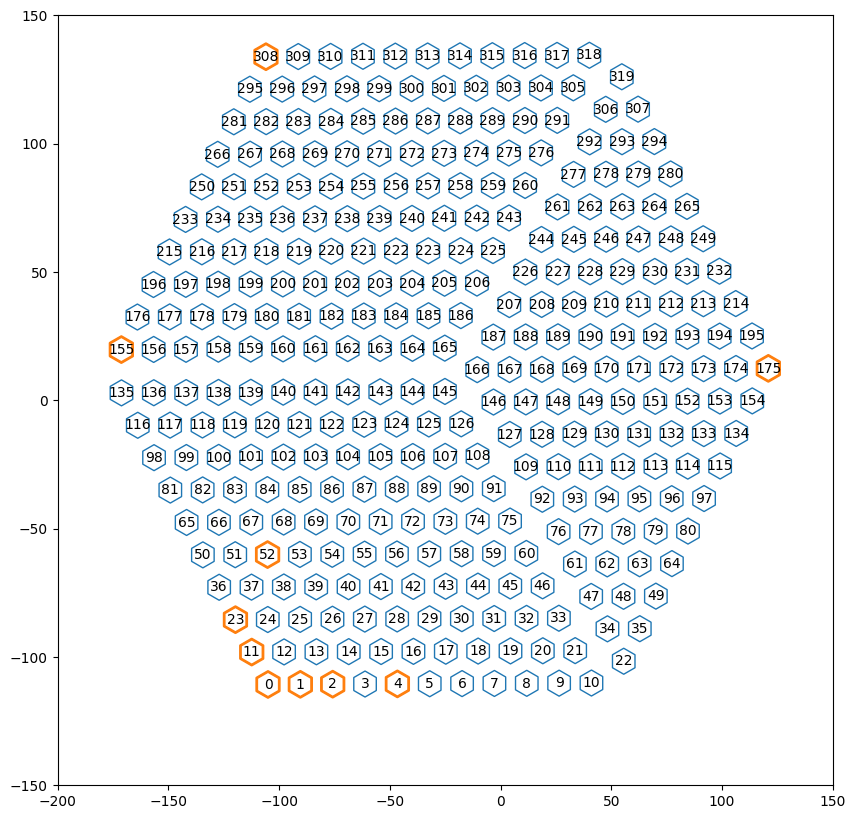

In [13]:
plt.figure(figsize=(10,10))
plt.scatter(meta.antpos_enu[:,0], meta.antpos_enu[:, 1], marker='h', color='none', lw=1, edgecolor='C0', s=350)

ants_to_highlight = sorted(set(sum(BASELINES_TO_INSPECT, start=())))
thispos = meta.antpos_enu[ants_to_highlight]

# thispos = meta.antpos_enu[blidx]
plt.scatter(thispos[:,0], thispos[:, 1], marker='h', color='none', lw=2, edgecolor='C1', s=350)

for i, pos in enumerate(meta.antpos_enu):
    if -200 < pos[0] < 150 and -150 < pos[1] < 150:
        plt.text(pos[0], pos[1], str(i), ha='center', va='center')

plt.xlim(-200,150)
plt.ylim(-150,150)

### Read the Data

In [14]:
nfiles_to_read = int(len(files) / EVERY_NTH_FILE)

In [15]:
nfiles_to_read

96

In [16]:
%%time 

all_data = np.zeros((nfiles_to_read, len(BASELINES_TO_INSPECT), meta.Nfreqs, 4), dtype=complex)
times = np.zeros(nfiles_to_read)
lsts = np.zeros(nfiles_to_read)

for itime, fl in enumerate(files[::EVERY_NTH_FILE]):
    if (itime + 1)%2 == 0:
        print(f"File {itime+1}/{nfiles_to_read}")

    with h5py.File(fl,'r') as _fl:
        all_data[itime] = _fl['Data']['visdata'][blidx, :, :]
        times[itime] = _fl['Header']['time_array'][0]
        lsts[itime] = _fl['Header']['lst_array'][0]

File 2/96
File 4/96
File 6/96
File 8/96
File 10/96
File 12/96
File 14/96
File 16/96
File 18/96
File 20/96
File 22/96
File 24/96
File 26/96
File 28/96
File 30/96
File 32/96
File 34/96
File 36/96
File 38/96
File 40/96
File 42/96
File 44/96
File 46/96
File 48/96
File 50/96
File 52/96
File 54/96
File 56/96
File 58/96
File 60/96
File 62/96
File 64/96
File 66/96
File 68/96
File 70/96
File 72/96
File 74/96
File 76/96
File 78/96
File 80/96
File 82/96
File 84/96
File 86/96
File 88/96
File 90/96
File 92/96
File 94/96
File 96/96
CPU times: user 2.22 s, sys: 10.9 s, total: 13.1 s
Wall time: 51.1 s


In [17]:
uvd = UVData.new(
    freq_array = meta.freq_array,
    polarization_array=meta.polarization_array,
    times=times,
    telescope=Telescope.from_hdf5(files[0]),
    antpairs=BASELINES_TO_INSPECT,
    do_blt_outer=True,
    integration_time=meta.integration_time[0],
    channel_width = meta.channel_width[0],
    blts_are_rectangular=True,
    time_axis_faster_than_bls=False,
    data_array=all_data.reshape((-1, meta.Nfreqs, meta.Npols)),
    vis_units="Jy"
)


## Obtain Power Spectrum Definition

In [18]:
cosmo = eor_utils.get_planck15_cosmo()

In [19]:
# Load beam-dependent normalization data
omegas_data_path = utils.BEAMDIR / 'vivaldi_solid_angle_and_reciever_power.h5'

with h5py.File(omegas_data_path, 'r') as h5f:
    Omega = h5f['directivity_integral'][()]
    Omegapp = h5f['directivity_square_integral'][()]
    
# hera_pspec beam initiated from pre-computed integral data
hpsb = hp.pspecbeam.PSpecBeamFromArray(Omega, Omegapp, utils.FREQS_DICT['H4C'], cosmo=cosmo)

In [20]:
pspec_def = eor_utils.get_pspec_from_covariance_file(utils.SKYDIR / 'raw' / 'covariance.h5')

Get the un-banded delay spectrum.

### Compute Pspec

In [21]:
uvd.pol_convention = 'sum'

In [22]:
uvd_pstokes = hp.pstokes.construct_pstokes(uvd, uvd, pstokes='pI', run_check=False)
ds = hp.PSpecData(dsets=[uvd_pstokes, uvd_pstokes], beam=hpsb)
ds.Jy_to_mK()

Cannot convert dset 1 Jy -> mK because vis_units = mK


In [23]:
ant_pairs = [ant_pair for ant_pair in uvd.get_antpairs() if ant_pair[0] != ant_pair[1]]
spw_ranges = [(i*200, (i + 1)*200) for i in range(7)]

uvp = ds.pspec(
    ant_pairs, ant_pairs,
    dsets=(0,1),
    pols=('pI', 'pI'),
    input_data_weight='identity',
    norm='I',
    taper='blackman-harris',
    spw_ranges=spw_ranges,
    store_window=False,
    verbose=True,
    allow_fft=True,
    exact_norm=False
)

# time average for each (delay, baseline)
uvp.average_spectra(time_avg=True, inplace=True)

In [24]:
k_bin_widths = 0.05
k_bins = np.arange(0, 2.5, k_bin_widths)

In [25]:
%%time

uvp_sphr = copy.deepcopy(uvp)

# average over (delay, baseline) for each k
uvp_sphr = hp.grouping.spherical_average(uvp_sphr, k_bins, k_bin_widths, run_check=False)

CPU times: user 1.95 s, sys: 4.97 ms, total: 1.96 s
Wall time: 272 ms


In [26]:
scaling = np.load("/lustre/aoc/projects/hera/Validation/H6C_IDR2/eor_rescaling_proper.npy")

In [27]:
zs = 1420e6 / uvd.freq_array - 1

In [28]:
scale_func = interp1d(zs[::-1], scaling[::-1]**2)  # square because power

In [29]:
def estimated_noise_level(z):
    """In P(k), at k=1 h/Mpc"""
    return 6e4 * (z/5.6)**6

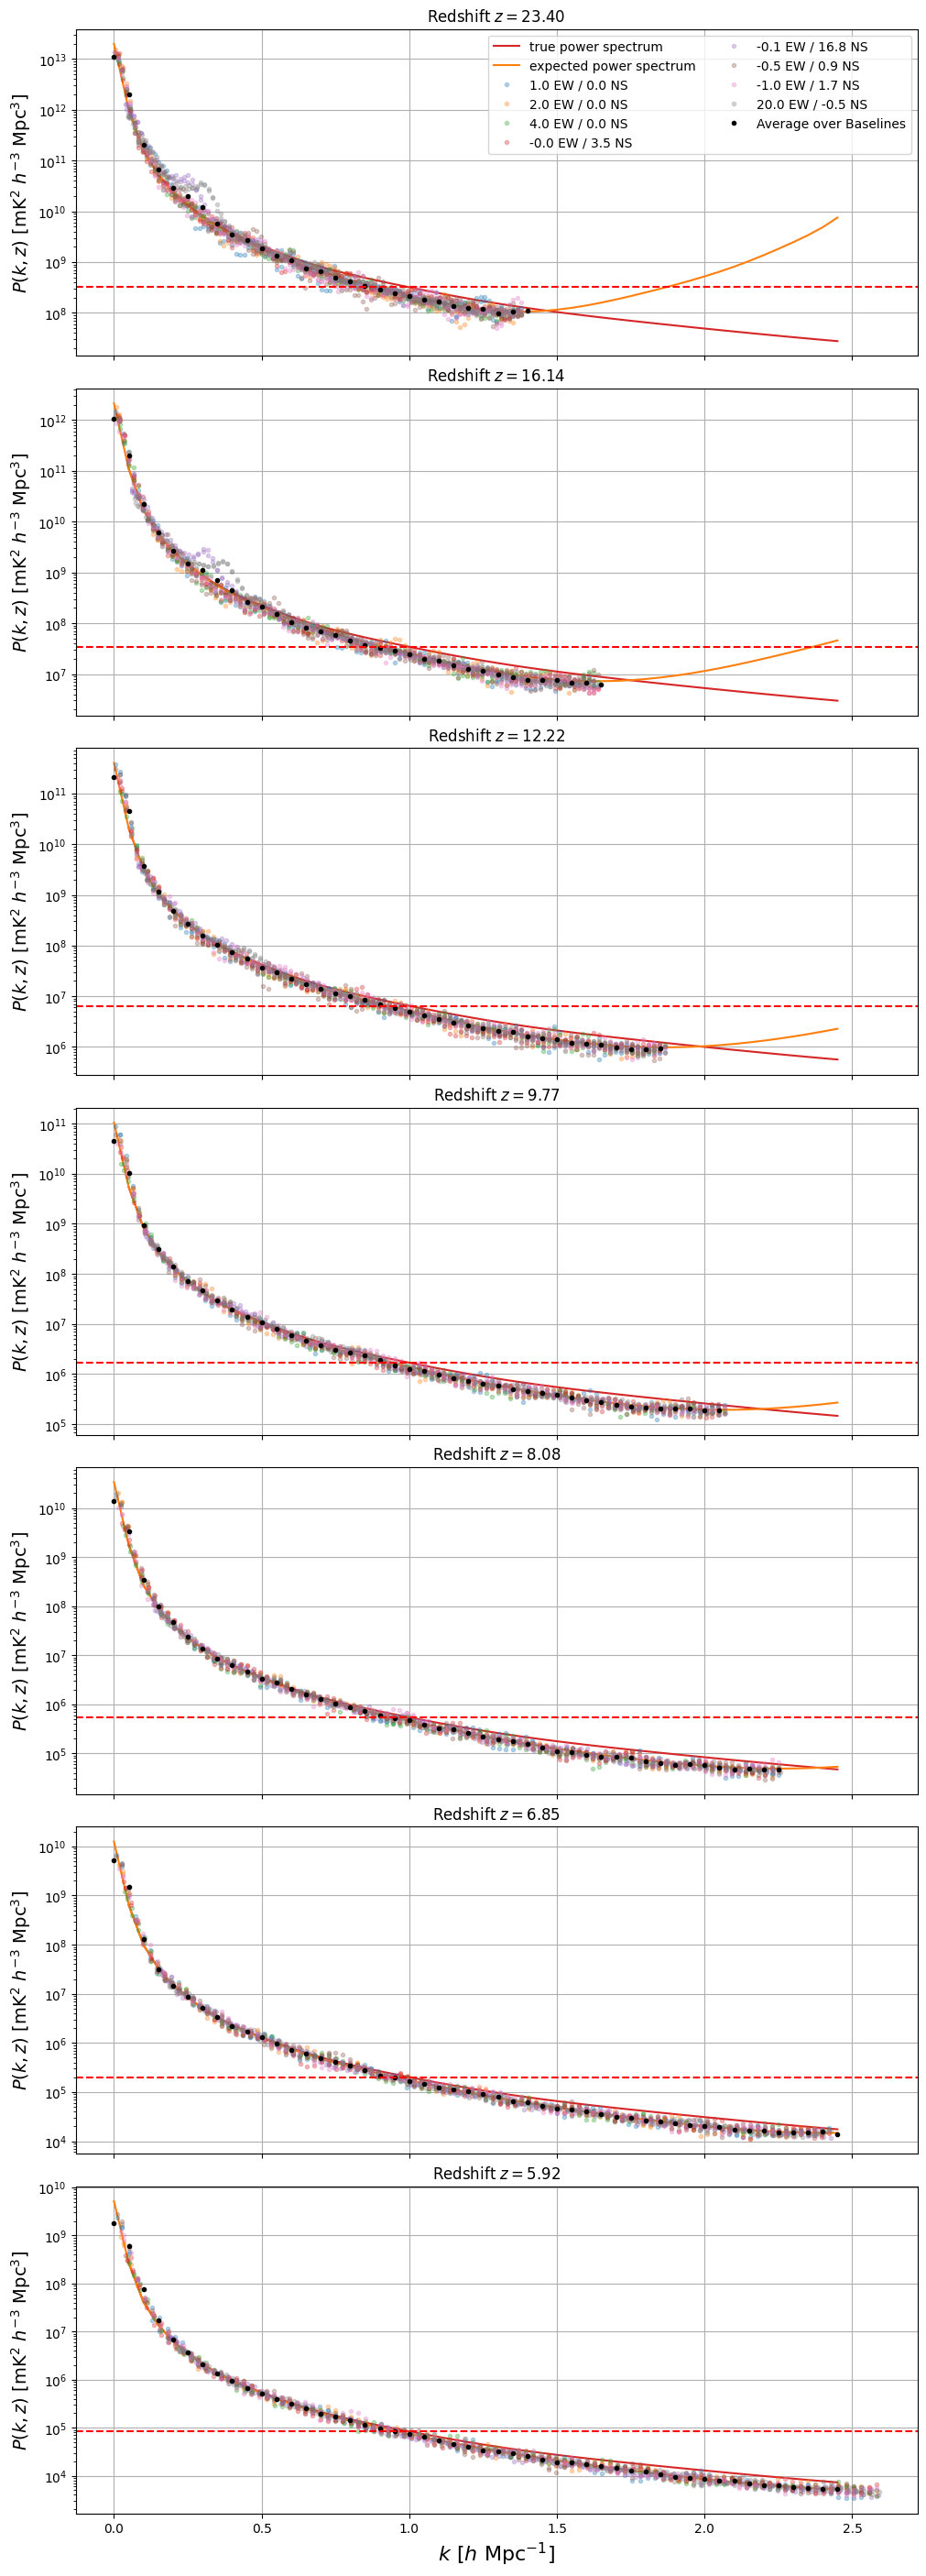

In [30]:
littleh = True
keys = uvp_sphr.get_all_keys()

fig, ax = plt.subplots(len(keys), 1, sharex=True, figsize=(10, 4*len(keys)), constrained_layout=True, gridspec_kw={"hspace": 0})

for i, key in enumerate(keys):
    z_mean = np.mean(eor_utils.get_zs(cosmo, uvp, i))
    noise_level = estimated_noise_level(z_mean)
    
    pspec_true = eor_utils.true_power_spectrum(cosmo, pspec_def, k_bins[1:], z_mean, rescale_func=scale_func, littleh=littleh)
    pspec_expected = eor_utils.expected_power_spectrum(cosmo, pspec_def, k_bins, uvp, spw=i, rescale_func=scale_func, littleh=littleh)

    ax[i].plot(k_bins[1:], pspec_true, label='true power spectrum', color='tab:red')
    ax[i].plot(k_bins, pspec_expected, label='expected power spectrum', color='tab:orange')

    # Each baseline
    for j, blpair in enumerate(uvp.get_blpairs()):
        kmag = np.sqrt(uvp.get_kparas(i)**2 + uvp.get_kperps(i)[j]**2)
        d = uvp.get_data((i, blpair, ('pI', 'pI')))[0].real
        uvw = uvd.uvw_array[j]
        ax[i].plot(kmag, d, '.', color=f"C{j}", alpha=0.3, label=f"{uvw[0]/14.6:.1f} EW / {uvw[1]/14.6:.1f} NS")

    # The average over all baselines
    pspec_est = uvp_sphr.get_data(key)[0].real
    ax[i].plot(k_bins, pspec_est, '.', label=f'Average over Baselines', color='k')

    ax[i].axhline(noise_level, color='r', ls='--')
    ax[i].set_yscale('log')
    ax[i].set_ylabel(r'$P(k,z)\ [{\rm mK}^2\ h^{-3}\ {\rm Mpc}^3]$', fontsize=14)
    ax[i].set_title(fr'Redshift $z ={z_mean:.2f}$')
    
    ax[i].grid()
    
ax[-1].set_xlabel(r'$k\ [h\ {\rm Mpc}^{-1}]$', fontsize=16)
    
ax[0].legend(ncols=2);